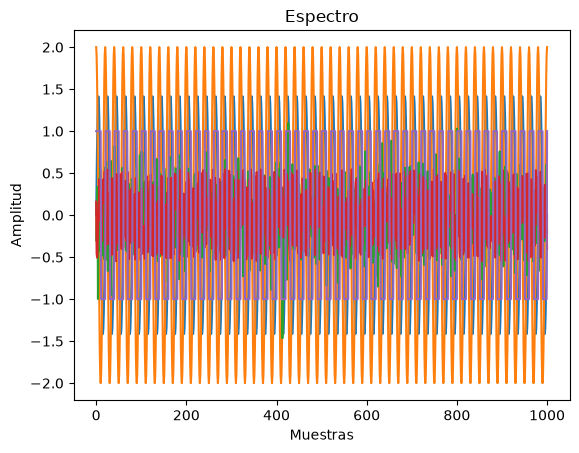

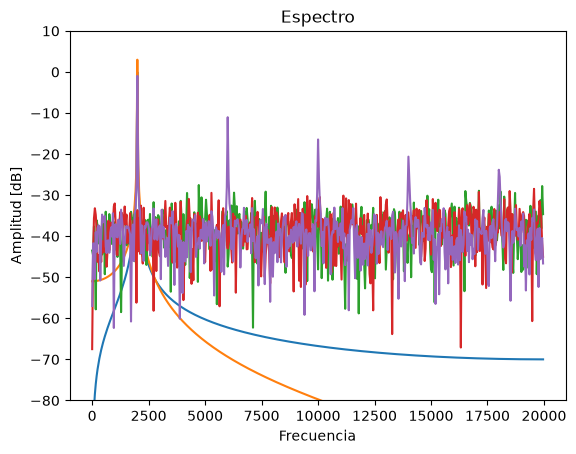

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

fs = 40000  # f de muestreo
N = 1000    # muestras


vmax = np.sqrt(2)           # amplitud máxima
dc = 0                      # valor de continua
ff = 2000                   # frecuencia de la señal
ph = 0                      # fase
nn = np.arange(0,N+1)       # vector de muestras


tt = nn
frec= np.arange(N//2) * fs/N  


xx1 =   vmax * np.sin(2*np.pi* ff*nn/fs + ph)                   # sinusoidal de 2kHz y 1W
xx1tr = (1/N) * np.fft.fft(xx1)
xx1tr_db = 10 * np.log10(2*(np.abs(xx1tr[:N//2]) ) ** 2)

xx2 =      2 * np.sin(2*np.pi* ff*nn/fs + np.pi/2)              # sinusoidal de 2kHz, 2W potencia media y desfasada pi/2 
xx2tr = (1/N) * np.fft.fft(xx2)
xx2tr_db = 10 * np.log10(2*(np.abs(xx2tr[:N//2]) ) ** 2)

xx3 =      1 * sp.signal.square(2*np.pi*ff*nn/fs)               #pulso rectangular de 2kHz y 1W potencia media
xx3tr = (1/N) * np.fft.fft(xx3) 
xx3tr_db = 10 * np.log10(2*(np.abs(xx3tr[:N//2]) ) ** 2)

rrn = np.random.normal(0 , 1/np.sqrt(10) , N+1)                 #ruido ~N, valor medio 0V y var 0.1W
rrntr = (1/N) * np.fft.fft(rrn)
rrntr_db = 10 * np.log10(2*(np.abs(rrntr[:N//2]) ) ** 2)

rru = np.random.uniform(-np.sqrt(1.2)/2 , np.sqrt(1.2)/2 , N+1) #ruido ~U, valor medio 0V y var 0.1W
rrutr = (1/N) * np.fft.fft(rru)
rrutr_db = 10 * np.log10(2*(np.abs(rrutr[:N//2]) ) ** 2)

plt.plot(tt,xx1)
plt.plot(tt,xx2)
plt.plot(tt,rrn)
plt.plot(tt,rru)
plt.plot(tt,xx3)
plt.title("Espectro")
plt.ylabel("Amplitud")
plt.xlabel("Muestras")
plt.show()

plt.plot(frec,xx1tr_db)
plt.plot(frec,xx2tr_db)
plt.plot(frec,rrntr_db)
plt.plot(frec,rrutr_db)
plt.plot(frec,xx3tr_db)
plt.ylim(-80,10)
plt.title("Espectro")
plt.ylabel("Amplitud [dB]")
plt.xlabel("Frecuencia")
plt.show()